# Which water mains to replace: the supplement

Companion to the main notebook, [watermains.ipynb](watermains.ipynb). The main notebook tells the modeling story; this one holds what a reader needs to trust it or reproduce it: the cleaning decisions and their counts, the exploratory views the features came from, the overdispersion evidence behind the frailty, the benchmark tuning protocol, the derivations behind Model 3's inference, fold-level posterior diagnostics, and the sensitivity of the decision rules to their assumed costs.

Everything runs from the same cached data pull and cross-validation caches as the main notebook (`watermains_cache.pkl`, `watermains_cv_seq97_*.pkl`, `watermains_cv_m4_*.pkl`, written by `dev/final_ladder_seq97.py` and `dev/m4_cv.py`). The companion module [`watermains.py`](watermains.py) carries the mechanical code and its unit tests.

In [1]:
import pickle

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import watermains as wm

breaks, mains, mains_geoms = wm.load_kitchener_data(cache_path="watermains_cache.pkl")
m, mb, pz_source = wm.build_modeling_frame(mains, breaks)
base = wm.static_frame(mains)
segs = wm.line_segments(mains_geoms)
FOLDS = list(range(2019, 2026))
cv = {t: pickle.loads(Path(f"watermains_cv_seq97_{t}.pkl").read_bytes()) for t in FOLDS}
m3 = {t: pickle.loads(Path(f"watermains_cv_m4_{t}.pkl").read_bytes()) for t in FOLDS}
print(
    f"{len(m)} modeled mains, {m['length_km'].sum():.0f} km; {len(mb)} MAIN break records after cleaning"
)

16127 modeled mains, 934 km; 2917 MAIN break records after cleaning


## Cleaning decisions

The raw pull is in better shape than most municipal data: every record is an active main with a plausible install year (1889-2026) and diameter (25-1200 mm), so the guards in `wm.build_modeling_frame` mostly pass everything through. Three decisions do bite, and each is a judgment call worth recording.

- **Spatial outliers.** Twelve MAIN break records sit at just two repeated coordinates far outside the city footprint (nine at one point, three at another), the signature of placeholder geocodes. Trimming the exact minimum and maximum longitudes removes them.
- **Unlinked breaks.** 83% of the remaining MAIN breaks carry an asset id matching an active main; the rest reference mains since renumbered or removed. Linked breaks feed the per-pipe counts and the history feature; unlinked ones still appear on the map but cannot join the per-pipe analysis.
- **Fringe pressure zones.** 36 mains sit in seven zones belonging to neighbouring systems (Waterloo, Cambridge, Breslau, Mannheim): a different utility's assets, no recorded breaks, some mislabeled. They are dropped.

One quirk to know about rather than fix: 311 linked breaks predate their main's recorded install year. Asset ids persist when a main is replaced, so a naive age-at-break can come out negative. The panel computes age from the recorded install year and both the exposure window and the history feature start no earlier than the record itself, so nothing breaks; a replaced main simply inherits its site's break history. That is arguably the right call, since the bedding, soil, and pressure conditions that broke the old pipe persist at the site.

In [2]:
mb_all = breaks[breaks["BREAK_TYPE"].eq("MAIN")]
lo, hi = mb_all["lon"].min(), mb_all["lon"].max()
linked = mb["ASSETID"].isin(set(mains["WATMAINID"]))
j = wm.attach_break_year(mb).merge(
    mains[["WATMAINID", "install_year"]], left_on="ASSETID", right_on="WATMAINID"
)
act = mains[mains["STATUS"] == "ACTIVE"]
print(
    f"records at the two outlier coordinates: {int((mb_all['lon'] == lo).sum())} + {int((mb_all['lon'] == hi).sum())}"
)
print(
    f"MAIN breaks after trim: {len(mb)}; linked to an active main: {int(linked.sum())} ({100 * linked.mean():.0f}%)"
)
print(
    f"active mains in dropped fringe zones: {int(act['PRESSURE_ZONE'].isin(wm.DROP_ZONES).sum())}"
)
print(
    f"linked breaks predating their main's install year: {int((j['break_year'] < j['install_year']).sum())}"
)

records at the two outlier coordinates: 9 + 3
MAIN breaks after trim: 2917; linked to an active main: 2415 (83%)
active mains in dropped fringe zones: 36
linked breaks predating their main's install year: 311


## Categories: consolidation

The material column has 13 raw levels, four of them nearly empty (PVCF 6 records, ST 5, HDPE IN CI 1, XXX 1). A `LowRankCategorical` kernel learns a rank-2 covariance between levels, and a level with one member gives it nothing to learn from, so near-duplicates fold into their parent (HDPE IN CI into HDPE) and the unidentifiable scraps into OTHER. Ten levels remain, coded by frequency so row 0 of every learned covariance is the most common material.

Pressure zones follow the same logic: 16 raw labels become 9 after the fringe-zone drop and folding RAW NO ZONE into OTHER.

In [3]:
wm.mat_value_counts_table(m)

material,mains,share
PVC,"8,055",49.9%
DI,"5,087",31.5%
CI,"2,011",12.5%
PVCO,597,3.7%
CPP,232,1.4%
AC,55,0.3%
HDPE,47,0.3%
PVCB,22,0.1%
COP,8,0.0%
PVCF,6,0.0%


In [4]:
wm.pz_value_counts_table(m, pz_source)

pressure_zone,mains,share
KIT 4,"10,520",65.1%
KIT 5,"2,352",14.6%
KIT 2W,"1,398",8.6%
KIT 6,988,6.1%
KIT 2E,305,1.9%
BRIDGEPORT,201,1.2%
KIT 4A,176,1.1%
KIT 2EA,172,1.1%
WAT 4,17,0.1%
RAW NO ZONE,15,0.1%


## Feature distributions

Age is bimodal: a postwar cast-iron and ductile-iron construction wave now 50 to 80 years old, and the PVC era from the 1980s on. Exposure spans orders of magnitude, which is why every model in the main notebook predicts a rate behind a log-exposure offset rather than a raw count. And the break counts are heavily zero inflated: 92.5% of mains have no linked break at all, with a long tail out to 13 breaks on a single main.

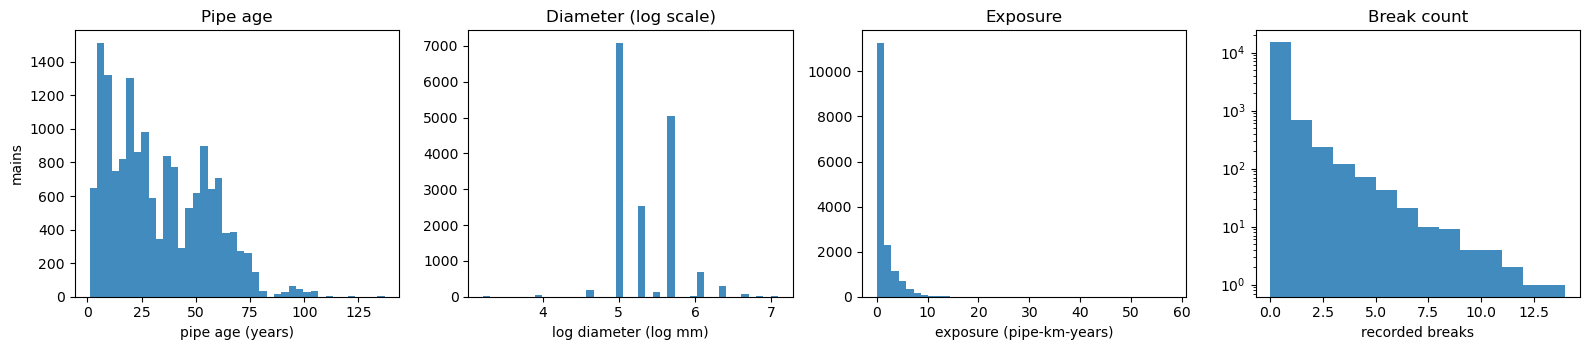

In [5]:
wm.plot_feature_hist(m)

## Break rate vs age, by material

Empirical decade-binned rates over each main's recorded lifetime, keeping bins with at least 50 km-years of exposure. Cast iron breaks at 0.2 to 0.5 per km-year in every cohort old enough to measure. Ductile iron climbs steadily with age, reaching about 0.18 per km-year in its sixties. PVC shows a mild early-life bump (installation defects surface in the first decade) and then stays near 0.02. The shape of the age effect depends on the material, which is why the main notebook's kernel multiplies an ARD Matern over age by a learned material covariance instead of assuming one shared age curve.

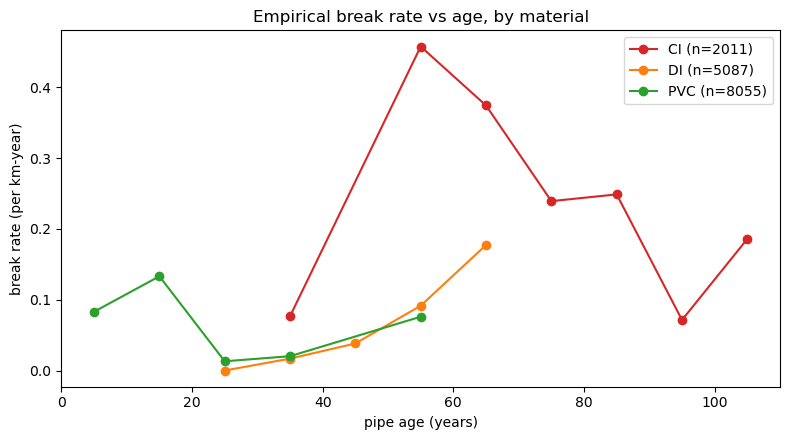

In [6]:
con = wm.consolidate_categories(m["MATERIAL"], wm.MAT_MAP)
fig, ax = plt.subplots(figsize=(8, 4.5))
for mat in ["CI", "DI", "PVC"]:
    sub = m[con == mat].assign(ab=(m.loc[con == mat, "age"] // 10) * 10)
    g = sub.groupby("ab").agg(n=("n_breaks", "sum"), e=("exposure", "sum"))
    g = g[g["e"] >= 50.0]  # drop bins with under 50 km-years of exposure
    ax.plot(g.index + 5, g["n"] / g["e"], "o-", color=wm.COLORS[mat], label=f"{mat} (n={len(sub)})")
ax.set_xlabel("pipe age (years)")
ax.set_ylabel("break rate (per km-year)")
ax.set_title("Empirical break rate vs age, by material")
ax.legend()
plt.tight_layout()
plt.show()

## Age at break, and recurrence

The typical linked break happens at age 45 (IQR 33 to 55), squarely in the postwar cohort. Recurrence is the sharper fact: only 7.5% of mains have any linked break, and mains with two or more carry 71% of all linked breaks, topping out at 13 on one main. The main notebook's repeat-breaker ratio and Model 3's frailty both trace back to this panel.

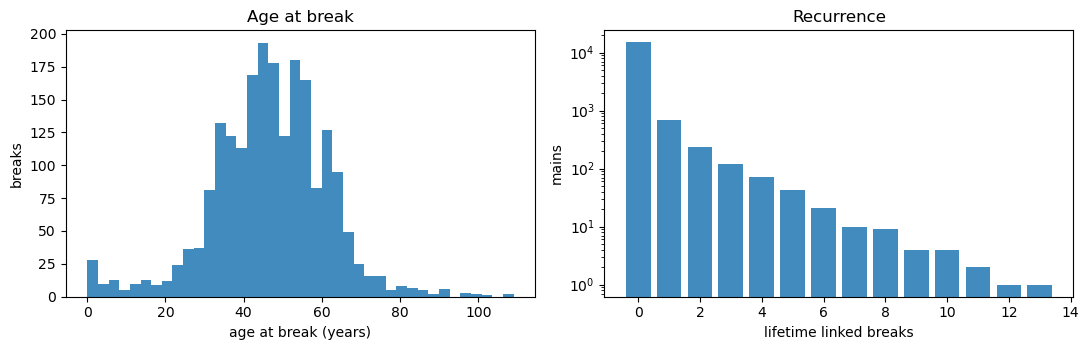

median age at break 45 (IQR 33-55); 7.5% of mains ever broke; mains with >=2 breaks carry 71% of linked breaks


In [7]:
mby = wm.attach_break_year(mb)
aab = (j["break_year"] - j["install_year"]).dropna()
counts = base["WATMAINID"].map(mby["ASSETID"].value_counts()).fillna(0).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(aab[aab >= 0], bins=40, color="tab:blue", alpha=0.85)
ax[0].set(xlabel="age at break (years)", ylabel="breaks", title="Age at break")
vc = counts.value_counts().sort_index()
ax[1].bar(vc.index, vc.values, color="tab:blue", alpha=0.85)
ax[1].set_yscale("log")
ax[1].set(xlabel="lifetime linked breaks", ylabel="mains", title="Recurrence")
plt.tight_layout()
plt.show()
print(
    f"median age at break {aab.median():.0f} (IQR {aab.quantile(0.25):.0f}-{aab.quantile(0.75):.0f}); "
    f"{(counts > 0).mean() * 100:.1f}% of mains ever broke; "
    f"mains with >=2 breaks carry {counts[counts >= 2].sum() / counts.sum() * 100:.0f}% of linked breaks"
)

## Overdispersion: the case for a frailty

The natural null says pipes differ only in length and observed years: Poisson counts with one citywide rate times each main's exposure. Lifetime counts reject it decisively. The observed variance-to-mean ratio is 3.2 against about 1.4 under the null (the null exceeds 1 only because exposure varies), the zero fraction sits above the replicated band, and the observed 13-break maximum lands at the outer edge of what the null can produce.

Covariates close part of the gap, and the main notebook's model criticism shows what remains after all of them: pipes that broke keep breaking at 6.8 times the rate of comparable pipes. At the pipe-year level the leftover overdispersion is mild (variance over mean 1.30 on the 2025 slice), so a Poisson likelihood per pipe-year is fine once the latent rate varies by pipe. What the data demand is persistence, a pipe-level effect that follows the pipe across years. That is Model 3's frailty, and the fitted budget gives it 16% of the explained variance.

In [8]:
n = m["n_breaks"].to_numpy(float)
expo = m["exposure"].to_numpy(float)
lam0 = n.sum() * expo / expo.sum()  # exposure-only null: one citywide rate
reps = np.random.default_rng(0).poisson(np.tile(lam0, (400, 1)))
y25 = cv[2025]["n_test"]
print(f"pipe-year view, 2025 slice: observed var/mean = {y25.var() / y25.mean():.2f}")
wm.ppc_count_stats(reps, n)

pipe-year view, 2025 slice: observed var/mean = 1.30


,var/mean,frac zero,max
observed,3.169920,0.924661,13.0000
replicated mean,1.386665,0.880623,7.7075
replicated 2.5%,1.325822,0.876228,5.0000
replicated 97.5%,1.450287,0.885163,12.0000


## The panel, and what leakage would look like

One row per pipe per year from 1997. The target is that year's linked breaks, exposure is one year of the pipe's length, age is measured at the row's year, and the history feature is the pipe's empirical break rate over `[1997, s)`, strictly before the row's own year $s$. A rate rather than a count, so the feature keeps its scale as the window grows and a model trained on 22 years transfers to a fold trained on 28.

The rows below follow the panel's most repeat-broken main through its own record: `hist` moves the year after each break, never in the break's own year. That one-year lag is the entire leakage defense, and `test_build_panel` in the companion module pins it down.

In [9]:
train25, test25 = wm.build_panel(mains, breaks, 2025.0)
tot = train25.groupby("pipe_idx")["y"].sum()
pid = tot.idxmax()  # the panel's most repeat-broken pipe
rows = train25[train25["pipe_idx"] == pid]
first = rows.loc[rows["y"] > 0, "year"].min()
rows[rows["year"].between(first - 2, first + 6)][["year", "age", "y", "hist"]].round(3)

,year,age,y,hist
7210,1997.0,45.0,3.0,0.000
15134,1998.0,46.0,1.0,7.207
23231,1999.0,47.0,1.0,4.805
31512,2000.0,48.0,0.0,4.004
40096,2001.0,49.0,0.0,3.003
49005,2002.0,50.0,0.0,2.402
58168,2003.0,51.0,0.0,2.002


## Tuning the gradient-boosting bar

Untuned `HistGradientBoostingRegressor` memorizes the panel's spiky per-row rates, so each fold runs an 80-configuration random search (fixed seed) over depth, leaves, learning rate, regularization, binning, and feature subsampling, scored on the last training year and never the test year. The winning configurations land all over the search space (learning rates 0.02 to 0.21, leaf limits 15 to 127, minimum leaf sizes 50 to 1000) with similar validation scores: the optimum is flat, and the search buys insurance against a bad default rather than finding a special configuration.

The caveat from the main notebook bears repeating because it shapes what the bar means: trees bin calendar year like any other feature and cannot extrapolate it, so every future year lands in the last histogram bin. Refit annually, that frozen level is a strong one-year forecast; asked about year two and beyond, it goes flat.

In [10]:
pd.DataFrame({t: cv[t]["hgb"]["params"] for t in FOLDS}).T.round(3).fillna("-")

,learning_rate,max_iter,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization,max_bins,max_features
2019,0.037,100.0,15.0,8.0,100.0,0.035,128.0,0.8
2020,0.213,400.0,15.0,4.0,500.0,2.462,63.0,0.8
2021,0.056,400.0,15.0,-,200.0,3.102,128.0,0.8
2022,0.021,400.0,63.0,4.0,500.0,0.346,63.0,1.0
2023,0.045,200.0,31.0,8.0,50.0,0.216,128.0,0.8
2024,0.022,100.0,127.0,4.0,1000.0,3.648,63.0,0.6
2025,0.125,100.0,15.0,4.0,50.0,6.532,255.0,0.8


## Model 3: derivations

The main notebook builds Model 3 in about a hundred visible lines. This section derives each piece: the variational family and its ELBO, the whitened unit-amplitude blocks, the budget prior in the coordinates that make it optimizable, the fixed-draw device that makes the objective deterministic, and the natural-gradient updates. Notation: rows $i$ carry covariates $x_i$ and log exposure $o_i$; components $k$ carry amplitudes $v_k$ and inducing values $u_k$; $\kappa$ and $\varepsilon$ are the year and pipe effects.

### The structured family and its ELBO

The latent is $f(x) = c + \sum_k \sqrt{v_k}\, f_k(x) + \kappa_{t(x)} + \varepsilon_{i(x)}$, each $f_k$ a unit-amplitude GP with inducing values $u_k = f_k(Z_k)$. The variational family keeps every prior conditional exactly and approximates only the inducing values and the random effects:

$$q(f_{1..K}, u_{1..K}, \kappa, \varepsilon) \;=\; \prod_k p(f_k \mid u_k)\, q(u_k) \;\cdot\; q(\kappa)\, q(\varepsilon)$$

Jensen's inequality on the marginal likelihood gives the ELBO, and because the family contains the exact conditionals $p(f_k \mid u_k)$, those densities cancel inside the expectation. No KL over $f$ survives:

$$\mathcal{L} \;=\; \sum_i \mathbb{E}_{q(f_i)}\!\left[\log p(y_i \mid f_i)\right] \;-\; \sum_k \mathrm{KL}\!\left(q(u_k) \,\|\, p(u_k)\right) \;-\; \mathrm{KL}\!\left(q(\kappa) \,\|\, p(\kappa)\right) \;-\; \mathrm{KL}\!\left(q(\varepsilon) \,\|\, p(\varepsilon)\right)$$

This is why sparse variational GPs pay only for their inducing values: the approximation error lives entirely in $q(u)$, never in the conditional draw of $f$ given $u$.

The data term needs only the marginal of $f_i$ under $q$, a Gaussian whose moments sum across independent components:

$$\mu_i = c + o_i + \sum_k \sqrt{v_k}\,\mu_{k,i} + m_{\kappa} + m_{\varepsilon}, \qquad \sigma^2_i = \sum_k v_k\,\sigma^2_{k,i} + s_{\kappa} + s_{\varepsilon}$$

For the Poisson likelihood with log link the expectation is closed form, via $\mathbb{E}[e^f] = e^{\mu + \sigma^2/2}$:

$$\mathbb{E}_q\!\left[\log p(y \mid f)\right] \;=\; y\,\mu \;-\; e^{\mu + \sigma^2/2} \;-\; \log y!$$

which is exactly what `variational_expectation` evaluates; a minibatch of $|B|$ rows scales the sum by $N/|B|$.

### Whitened, unit-amplitude component blocks

Each block stores its variational distribution in whitened coordinates: with $K_{mm} = L L^\top$, write $u = L w$ and put $q(w) = \mathcal{N}(m, S)$ against the whitened prior $w \sim \mathcal{N}(0, I)$. The marginals at the batch rows and the block's KL are

$$A = L^{-1} K(Z, X), \qquad \mu = A^\top m, \qquad \sigma^2 = k_{\mathrm{diag}} - \mathrm{diag}(A^\top A) + \mathrm{diag}(A^\top S A)$$

$$\mathrm{KL} \;=\; \tfrac{1}{2}\left(\mathrm{tr}\, S + m^\top m - M - \log\det S\right)$$

five lines of code in the main notebook's `whitened_block`. Whitening puts the identity prior on every block, which is what lets a single natural-gradient rule serve all of them.

Amplitudes stay outside the blocks. Every kernel is pinned to unit scale (Matern variance 1, categorical factors normalized), and a component enters the latent as $\sqrt{v_k} f_k$. Since $K_{mm}$ never depends on $v_k$, one Cholesky per component per step serves all 16 budget draws; an amplitude inside the kernel would force one factorization per draw, sixteen times the linear algebra for the same posterior. The same argument keeps lengthscales as point estimates: sampled lengthscales would change $K_{mm}$ per draw and the sharing would die.

The mean-field blocks stay in natural coordinates with prior variance from the budget. Elementwise,

$$\mathrm{KL}\!\left(\mathcal{N}(m, s) \,\|\, \mathcal{N}(0, v)\right) \;=\; \tfrac{1}{2}\left(\frac{s + m^2}{v} - 1 + \log v - \log s\right)$$

the `kl_year` and `kl_eps` lines of the construction.

### The budget prior, in coordinates that optimize

The R2D2M2 prior puts $R^2 = W/(W + \tilde\sigma^2) \sim \mathrm{Beta}(a, b)$ on the total budget $W$, with $\tilde\sigma^2 = 1/\bar y$ the Poisson pseudo-variance, and splits $W$ across components with a uniform Dirichlet: $v_k = W \phi_k$. Three changes of variables land the density on $\log v$, the coordinates the optimizer sees.

From $R^2$ to $W$: $\;p(W) = \mathrm{Beta}\!\left(\frac{W}{W + \tilde\sigma^2};\, a, b\right)\dfrac{\tilde\sigma^2}{(W + \tilde\sigma^2)^2}$.

From $(W, \phi)$ to $v$: the map has Jacobian $W^{K-1}$ and the uniform Dirichlet density is $\Gamma(K)$, so $p(v) = p(W)\,\Gamma(K)\, W^{-(K-1)}$.

From $v$ to $\log v$: multiply by $\prod_k v_k$.

Dropping the Beta normalizing constant, the log density is

$$\log p(\log v) = (a-1)\log R^2 + (b-1)\log(1 - R^2) + \log\tilde\sigma^2 - 2\log(W + \tilde\sigma^2) + \log\Gamma(K) - (K-1)\log W + \sum_k \log v_k$$

term for term the body of `wm.r2d2_log_prior`.

The coordinates matter more than they look. In the natural $(R^2, \phi)$ parameterization the objective is nearly flat along reallocations: shifting budget between components while the component functions rescale to compensate changes the ELBO only weakly, so gradients through the stick-breaking transform are tiny and the allocation barely moves from wherever it starts. In $\log v_k$ each component's variance takes a direct, well-scaled gradient. Same posterior, different geometry. Model 2's MAP budget and Model 3's variational budget both live in log-variance coordinates for this reason.

### Fixed base draws: a deterministic objective

The budget block $q(\log v_{1..5}, c) = \mathcal{N}(q_{\mathrm{loc}}, \mathrm{diag}(q_{\mathrm{sd}}^2))$ enters the ELBO through an expectation over a 6-dimensional standard normal. ADVI would redraw that noise every step. DADVI (Giordano, Ingram, and Broderick 2024) draws $\varepsilon_{1..S}$ once and fixes them, so every step averages the same $S$ paths:

$$\mathcal{L}(q) \;\approx\; \frac{1}{S}\sum_{s=1}^{S} \ell\!\left(q_{\mathrm{loc}} + q_{\mathrm{sd}} \odot \varepsilon_s\right) \;+\; \mathrm{entropy}, \qquad \varepsilon_s \text{ fixed}$$

The stochastic objective becomes a deterministic sample-average approximation: convergence can be judged on the actual objective, runs reproduce exactly, and any two configurations compared under the same draws share their Monte Carlo noise. SAA error grows with the dimension of the sampled block, and this setting is near the best case: 6 of roughly a hundred thousand variational dimensions are sampled, everything else integrates analytically, so $S = 16$ is plenty. The entropy of the budget block is analytic, $\sum \log q_{\mathrm{sd}} + \mathrm{const}$. One source of randomness remains by choice: the data term is minibatched, so training is SAA over the budget block and plain SGD over rows.

### Natural-gradient updates for every Gaussian block

For a Gaussian $q = \mathcal{N}(m, S)$ the natural parameters are $(S^{-1}m,\, -\tfrac{1}{2}S^{-1})$, and the natural gradient of the ELBO equals the ordinary gradient taken with respect to the expectation parameters $(m,\, S + mm^\top)$ (Khan and Lin 2017). Written back in $(m, S)$, a step of size $\gamma$ from gradients $g_m = \partial\mathcal{L}/\partial m$ and $g_S = \partial\mathcal{L}/\partial S$ is

$$S_{\mathrm{new}}^{-1} = S^{-1} - 2\gamma\, g_S, \qquad m_{\mathrm{new}} = S_{\mathrm{new}}\left(S^{-1}m + \gamma\,(g_m - 2\, g_S\, m)\right)$$

On a Gaussian target the step with $\gamma = 1$ lands exactly on that target in one move; the unit tests of `wm.ngd_update_full` and `wm.ngd_update_diag` assert precisely this, and near conjugacy the step stays close to that ideal. When $\gamma$ is too aggressive the precision update can lose positive definiteness; the implementation halves $\gamma$ and retries, up to six times, so a bad step degrades into a smaller one instead of a crash. Mean-field blocks use the same two lines elementwise on variances. The production schedule ramps $\gamma$ to 0.02 with a decay after step 400, and Adam handles every point-estimated parameter alongside.

## Fold-level posteriors

Seven independent walk-forward fits are seven chances for the budget to land somewhere else. It does not move. The allocation stays within a few points of (0.21, 0.23, 0.33, 0.07, 0.16) across folds, $R^2$ holds near 0.005, the year-shock scale stays near 0.25 and the frailty scale near 0.37, and the trend lengthscale comes out at a few decades, so the trend bends gently within the record and extrapolates one year out without drama.

The iid year effects are the sharpest reproducibility check: estimated on seven different training windows, the shared years agree nearly point for point.

In [11]:
rows = []
for t in FOLDS:
    d = m3[t]
    v = np.exp(d["q_loc"][:5] + 0.5 * d["q_sd"][:5] ** 2)
    phi = v / v.sum()
    rows.append(
        {
            "fold": t,
            **{
                f"phi {nm}": round(float(p), 3)
                for nm, p in zip(["base", "trend", "hist", "year", "frailty"], phi)
            },
            "R2": round(float(v.sum() / (v.sum() + d["sigma2"])), 4),
            "sigma year": round(float(np.sqrt(v[3])), 2),
            "sigma frailty": round(float(np.sqrt(v[4])), 2),
            "ls trend": round(d["ls_trend"], 2),
            "best step": d["best_step"],
        }
    )
tbl = pd.DataFrame(rows).set_index("fold")
yr_sd = train25["year"].std()
K = np.array([m3[t]["m_y_all"][:22] for t in FOLDS])  # shared trained years 1997-2018
print(
    f"trend lengthscale {tbl['ls trend'].min():.1f}-{tbl['ls trend'].max():.1f} standardized "
    f"= {tbl['ls trend'].min() * yr_sd:.0f}-{tbl['ls trend'].max() * yr_sd:.0f} calendar years; "
    f"minimum pairwise correlation of shared-year kappas: {np.corrcoef(K).min():.2f}"
)
tbl

trend lengthscale 3.0-4.0 standardized = 24-31 calendar years; minimum pairwise correlation of shared-year kappas: 0.90


,phi base,phi trend,phi hist,phi year,phi frailty,R2,sigma year,sigma frailty,ls trend,best step
fold,,,,,,,,,,
2019,0.210,0.249,0.328,0.072,0.141,0.0058,0.25,0.35,3.63,1850
2020,0.201,0.229,0.347,0.075,0.150,0.0056,0.25,0.36,3.86,2550
2021,0.209,0.238,0.338,0.069,0.146,0.0057,0.25,0.36,3.90,2750
2022,0.198,0.269,0.314,0.059,0.159,0.0053,0.22,0.36,3.95,1750
2023,0.247,0.188,0.349,0.054,0.161,0.0054,0.21,0.37,3.70,2950
2024,0.200,0.221,0.336,0.085,0.158,0.0055,0.28,0.38,3.78,2950
2025,0.203,0.206,0.315,0.092,0.184,0.0048,0.27,0.38,3.01,2800


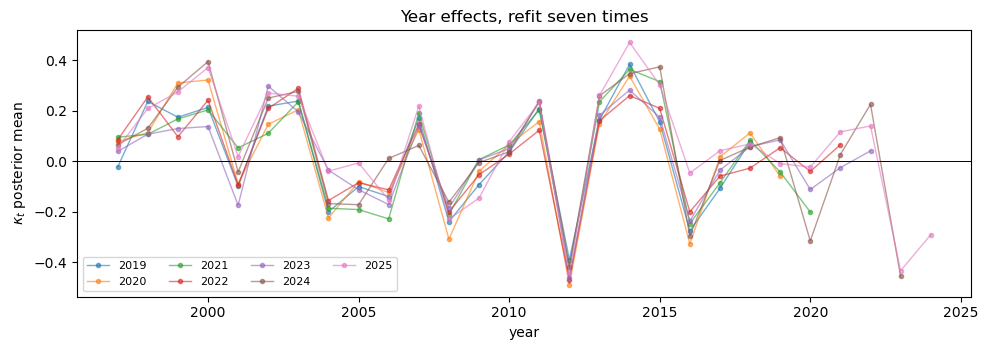

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for t in FOLDS:
    ky = m3[t]["m_y_all"][:-1]  # the fold's trained years, 1997..t-1
    ax.plot(np.arange(1997, t), ky, "-o", ms=3, lw=1, alpha=0.6, label=str(t))
ax.axhline(0.0, color="k", lw=0.7)
ax.set(xlabel="year", ylabel=r"$\kappa_t$ posterior mean", title="Year effects, refit seven times")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Integrating the predictive changes the action

The replacement rule compares expected break cost against replacement cost, and the expectation runs over the predictive distribution, not through its mode. With a lognormal latent the difference is $e^{\mu + \sigma^2/2}$ against $e^{\mu}$: uncertain pipes get pushed up. The comparison below runs the rule both ways on the 2025 fold using Model 2's latent moments (the scatter needs $\mu$ and $\sigma^2$ separately, which Model 3's draw-based caches do not store), with the notebook's standing prices: \$25k per break, a 30-year horizon at year-2025 conditions, and replacement at $(150 + 0.7 \cdot \mathrm{diameter\ in\ mm})$ dollars per metre.

Every plug-in pick survives integration, and 17 mains enter on uncertainty alone: their central rate sits below the threshold, but enough posterior mass lies above it that deferral is the expensive gamble.

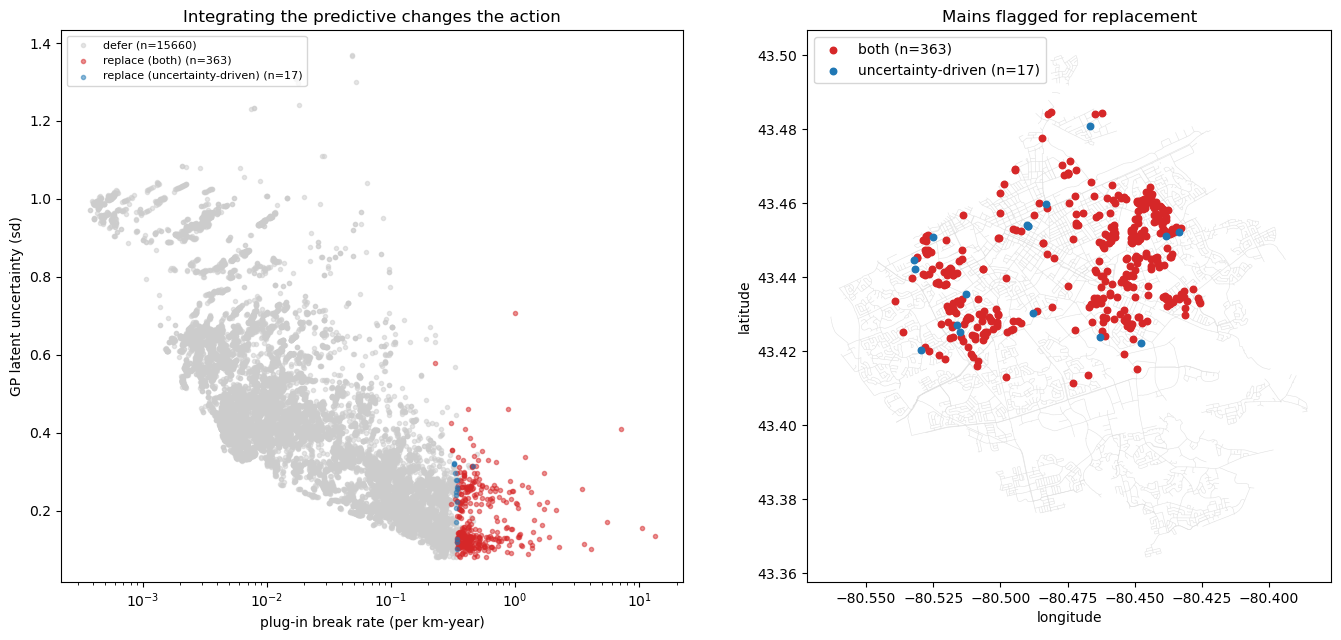

integrated rule flags 380, plug-in 363; uncertainty-driven additions: 17; plug-in-only picks: 0


In [13]:
fm, fv = cv[2025]["m2"]["fm"], cv[2025]["m2"]["fv"]
L = test25["length_km"].to_numpy(float)
rc = wm.replacement_cost(test25["diam"].to_numpy(float), L)
repl_int = wm.replace_decision(wm.latent_to_rate(fm, fv) * L * wm.H_YEARS, rc)
repl_plug = wm.replace_decision(np.exp(fm) * L * wm.H_YEARS, rc)
wm.plot_decision_map(test25, segs, repl_int, repl_plug, np.exp(fm), np.sqrt(fv))
print(
    f"integrated rule flags {int(repl_int.sum())}, plug-in {int(repl_plug.sum())}; "
    f"uncertainty-driven additions: {int((repl_int & ~repl_plug).sum())}; "
    f"plug-in-only picks: {int((repl_plug & ~repl_int).sum())}"
)

## Sensitivity: the economics set the cut line

The newsvendor budget moves with the cost ratio exactly as its critical fractile says it should. At the notebook's 5:1 surge-to-idle ratio the 2025 budget is 78 breaks, the 83rd percentile of the predictive and, as it happens, exactly the realized 2025 count. Halve the asymmetry and it drops to 75; push toward 15:1 and it climbs to 83. A few breaks either way: annual provisioning is robust to the exact prices.

The replacement plan is not. Across plausible break costs (\$15k to \$40k) and horizons (15 to 50 years), the flagged set swings from zero mains to two thousand and the capital from \$0 to \$40M, because the rule thresholds a continuous ranking and the threshold is pure economics. That is not a defect of the model. The model's defensible contribution is the ranking (the capture curve of the main notebook); where to stop spending along it belongs to the cost assumptions, and this table is what handing that choice to a budget owner looks like.

In [14]:
EN = m3[2025]["EN"]
VN = m3[2025]["VN"]
tot = np.random.default_rng(7).normal(EN.sum(), np.sqrt(VN.sum()), 4000)
nv_tbl = pd.DataFrame(
    [
        {
            "c_surge ($k)": cs // 1000,
            "c_idle ($k)": ci // 1000,
            "fractile q": round(cs / (cs + ci), 2),
            "budget B* (breaks)": wm.newsvendor_budget(tot, c_surge=cs, c_idle=ci).b_star,
        }
        for cs, ci in [(20000, 8000), (40000, 16000), (40000, 8000), (60000, 4000)]
    ]
)
repl_tbl = pd.DataFrame(
    [
        {
            "C_break ($k)": cb // 1000,
            "horizon (years)": H,
            "mains flagged": int(d.sum()),
            "capital ($M)": round(rc[d].sum() / 1e6, 1),
        }
        for cb in (15000, 25000, 40000)
        for H in (15, 30, 50)
        for d in [wm.replace_decision(EN * H, rc, c_break=cb)]
    ]
)
display(nv_tbl)
repl_tbl

,c_surge ($k),c_idle ($k),fractile q,budget B* (breaks)
0,20,8,0.71,75
1,40,16,0.71,75
2,40,8,0.83,78
3,60,4,0.94,83


,C_break ($k),horizon (years),mains flagged,capital ($M)
0,15,15,0,0.0
1,15,30,46,1.9
2,15,50,307,10.9
3,25,15,17,0.8
4,25,30,307,10.9
5,25,50,1027,25.0
6,40,15,165,5.6
7,40,30,930,23.7
8,40,50,1999,40.7


## Reproducing all of this

`dev/final_ladder_seq97.py` refits Models 1 and 2 and both benchmarks across the seven folds; `dev/m4_cv.py` refits Model 3 (roughly 25 minutes per fold) and writes the caches this notebook reads. A first run downloads the open data afresh into `watermains_cache.pkl`. `pytest notebooks/watermains.py` runs the unit tests, including the panel leakage guard and the one-step-exactness tests behind the natural-gradient updates.

Back to the main story: [watermains.ipynb](watermains.ipynb).